# Отчёт о воспроизведении: Cut Your Losses in Large-Vocabulary Language Models

E. Wijmans et al., ICLR 2025 ([arXiv:2411.09009](https://arxiv.org/abs/2411.09009)), код авторов — [apple/ml-cross-entropy](https://github.com/apple/ml-cross-entropy).

Ноутбук только читает результаты из `results/`. Сами эксперименты — в `01_benchmark.ipynb` (память, время, разреженность) и `02_finetune.ipynb` (обучение).

### Что проверяем

| # | Утверждение статьи | Где в статье | Раздел |
|---|---|---|---|
| 1 | Фильтрация градиента не искажает градиент | разд. 4.3, 5.2 | 1 |
| 2 | CCE сокращает память на loss + градиент почти до размера самих градиентов | табл. 1 | 2 |
| 3 | …без потери скорости; фильтрация и сортировка словаря ускоряют backward | табл. 1 | 2 |
| 4 | Softmax крайне разрежен: < 0,02% элементов выше порога bf16, ниже порога уже с ~50-го токена | рис. 3, разд. 5.2 | 3 |
| 5 | Кривые обучения с CCE и без неё совпадают | рис. 4 | 4 |
| 6 | Освободившаяся память позволяет увеличить батч | рис. 1 | 4 |

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

RES = Path("results")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
C_OURS, C_PAPER, C_HF, C_CCE = "tab:blue", "tab:gray", "tab:blue", "tab:orange"

env = json.loads((RES / "env.json").read_text())
env

{'torch': '2.7.1+cu118',
 'triton': '3.3.1',
 'transformers': '4.48.2',
 'gpu': 'NVIDIA H100 80GB HBM3 MIG 3g.40gb'}

### Условия эксперимента и отличия от статьи

| | Статья | У нас |
|---|---|---|
| GPU | A100-SXM4, 80 ГБ | H100, MIG-слайс 3g.40gb: 60 SM из 132, 40 ГБ |
| PyTorch / Triton | 2.4.1 / — | 2.7.1 / 3.3.1 |
| Модель | Gemma 2 2B Instruct | Gemma 2 2B Instruct |
| Данные бенчмарка | Alpaca, батч 8192 токена | Alpaca, батч 8192 токена (только токены ответов) |
| Повторы замера | среднее по 5 сидам | 2 прогрева + 5 повторов |
| Точное накопление градиента | суммирование Кэхэна (bf16 + bf16-поправки) | fp32-буфер: на Triton ≥ 3.2 пакет выбирает его вместо Кэхэна |
| CCE без сортировки словаря | есть в табл. 1 | не измерено: в публичном API нет переключателя |
| Liger Kernels, Torch Tune | есть в табл. 1 | не измерялись |
| Fine-tuning | полный, 4 модели, ~700 шагов, 5 сидов | LoRA r = 16, Gemma 2 2B, 300 шагов, 1 сид, 500 примеров (≈ 5 эпох) |

Baseline — обычный PyTorch в порядке HF: логиты и softcap в bf16, перевод в fp32 перед cross-entropy.

## 1. Корректность градиентов

Каждый вариант сравнивается с Baseline на одних и тех же E (8192 × 2304), C (256 000 × 2304) и targets.

In [2]:
corr = pd.read_csv(RES / "bench_correctness.csv").set_index("method")
corr[["loss_abs_diff", "grad_E_rel_err", "grad_C_rel_err"]].style.format(
    {"loss_abs_diff": "{:.1e}", "grad_E_rel_err": "{:.2%}", "grad_C_rel_err": "{:.2%}"}
)

,loss_abs_diff,grad_E_rel_err,grad_C_rel_err
method,,,
torch.compile,3.2e-04,1.72%,0.47%
CCE,4.0e-04,1.92%,0.81%
CCE (no grad filter),4.0e-04,2.25%,0.86%
CCE (fp32 accum),3.9e-04,1.73%,0.47%
CCE-Kahan-FullC,4.0e-04,1.73%,0.47%
CCE-Kahan-FullE,4.0e-04,1.72%,0.47%


- Loss отличается от Baseline не больше чем на 4·10⁻⁴: Baseline считает softcap в bf16, CCE — в fp32 внутри ядра.
- Относительная ошибка ∇E около 1,7–2,3% — это предел точности bf16, а не ошибка CCE: `torch.compile` с той же математикой даёт те же 1,7%.
- Фильтрация добавляет к ошибке ∇E около 0,2 п.п. Без фильтрации ошибка даже чуть больше: больше мелких слагаемых теряется при сложении в bf16. Точное накопление (fp32) возвращает ошибку к уровню `torch.compile`.
- Косинусы в `bench_correctness.csv` чуть больше 1 — погрешность float32 на ~590 млн элементов, они не показаны.

## 2. Память и время (аналог таблицы 1)

Память — пик сверх уже выделенной перед замеряемой фазой; время — среднее по 5 повторам.
**Lower bound** = размер самих ∇E + ∇C: меньше в режимах с backward не может занять ни один метод.

In [3]:
# Таблица 1 статьи: (память МБ, время мс) для loss / grad / loss+grad.
PAPER = {
    "Baseline":             {"loss": (24000, 82), "grad": (16000, 122), "loss+grad": (28000, 208)},
    "torch.compile":        {"loss": (4000, 49),  "grad": (12000, 92),  "loss+grad": (16000, 143)},
    "CCE":                  {"loss": (1, 46),     "grad": (1163, 100),  "loss+grad": (1164, 145)},
    "CCE (no grad filter)": {"loss": (0.09, 45),  "grad": (1163, 314),  "loss+grad": (1162, 357)},
    "CCE (fp32 accum)":     {"loss": (1, 47),     "grad": (2325, 114),  "loss+grad": (2326, 160)},  # ↔ CCE-Kahan
    "CCE-Kahan-FullC":      {"loss": (1, 47),     "grad": (2326, 268),  "loss+grad": (2326, 313)},
    "CCE-Kahan-FullE":      {"loss": (1, 47),     "grad": (2326, 247),  "loss+grad": (2326, 292)},
}
LOWER_BOUND_MB = 1161

raw = pd.read_csv(RES / "bench_raw.csv")
assert (raw["status"] == "ok").all()
methods = list(dict.fromkeys(raw["method"]))

rows = []
for _, r in raw.iterrows():
    p_mem, p_time = PAPER[r["method"]][r["mode"]]
    rows.append({"method": r["method"], "mode": r["mode"],
                 "память, МБ": r["peak_mem_mb"], "статья, МБ": p_mem,
                 "время, мс": r["time_ms"], "статья, мс": p_time})
t1 = (pd.DataFrame(rows)
      .pivot(index="method", columns="mode")
      .swaplevel(axis=1)
      .reindex(columns=["loss", "grad", "loss+grad"], level=0)
      .reindex(methods))
t1 = t1[[(m, c) for m in ["loss", "grad", "loss+grad"] for c in ["память, МБ", "статья, МБ", "время, мс", "статья, мс"]]]
print(f"Lower bound (∇E + ∇C) = {LOWER_BOUND_MB} МБ")
t1.style.format("{:,.1f}")

Lower bound (∇E + ∇C) = 1161 МБ


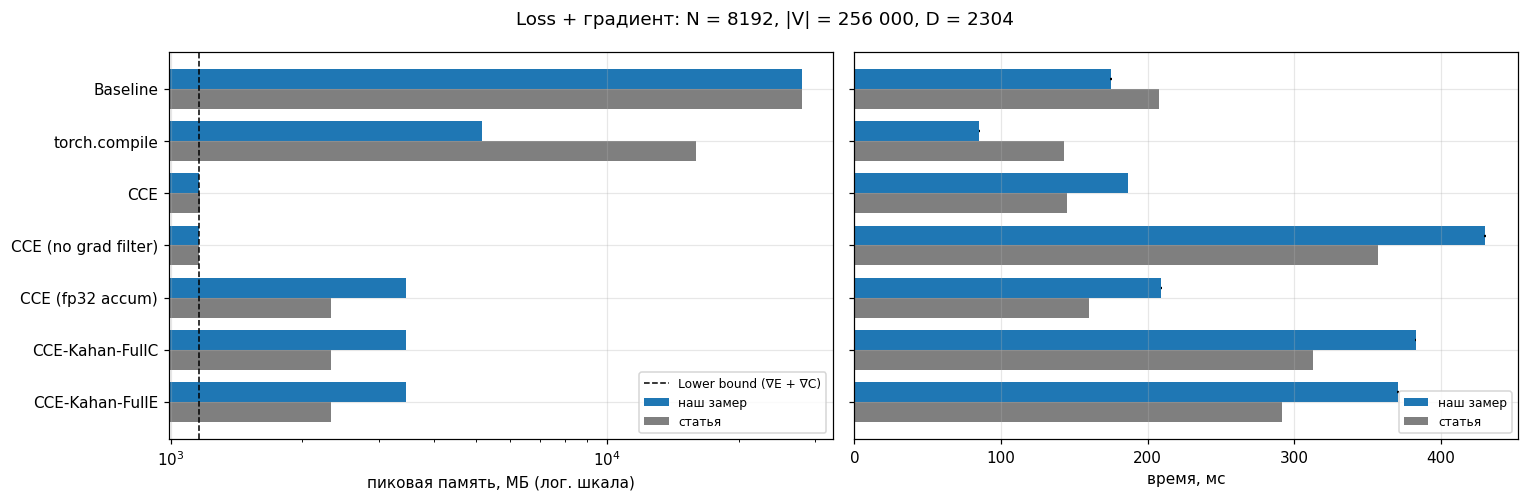

In [4]:
lg = raw[raw["mode"] == "loss+grad"].set_index("method").reindex(methods)
paper_lg = pd.DataFrame({m: PAPER[m]["loss+grad"] for m in methods}, index=["mem", "time"]).T

y = np.arange(len(methods))
h = 0.38
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)

axes[0].barh(y - h / 2, lg["peak_mem_mb"], h, color=C_OURS, label="наш замер")
axes[0].barh(y + h / 2, paper_lg["mem"], h, color=C_PAPER, label="статья")
axes[0].axvline(LOWER_BOUND_MB, color="black", ls="--", lw=1, label="Lower bound (∇E + ∇C)")
axes[0].set_xscale("log")
axes[0].set_xlabel("пиковая память, МБ (лог. шкала)")

axes[1].barh(y - h / 2, lg["time_ms"], h, xerr=lg["time_ms_std"], color=C_OURS, label="наш замер")
axes[1].barh(y + h / 2, paper_lg["time"], h, color=C_PAPER, label="статья")
axes[1].set_xlabel("время, мс")

axes[0].set_yticks(y, methods)
axes[0].invert_yaxis()
for ax in axes:
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("Loss + градиент: N = 8192, |V| = 256 000, D = 2304")
fig.tight_layout()

Удобнее сравнивать не абсолютные числа (у нас другое железо), а отношения внутри каждого замера:

In [5]:
def ratio(df_mem_time, a, b, col):
    return df_mem_time.loc[a, col] / df_mem_time.loc[b, col]

ours = lg.rename(columns={"peak_mem_mb": "mem", "time_ms": "time"})
pairs = [
    ("память: Baseline / CCE",                 "Baseline", "CCE", "mem"),
    ("память: torch.compile / CCE",            "torch.compile", "CCE", "mem"),
    ("время: CCE / Baseline",                  "CCE", "Baseline", "time"),
    ("время: CCE / torch.compile",             "CCE", "torch.compile", "time"),
    ("время: без фильтрации / с фильтрацией",  "CCE (no grad filter)", "CCE", "time"),
    ("время: FullC / точное накопление",       "CCE-Kahan-FullC", "CCE (fp32 accum)", "time"),
    ("время: FullE / точное накопление",       "CCE-Kahan-FullE", "CCE (fp32 accum)", "time"),
]
ratios = pd.DataFrame(
    [{"отношение": name, "у нас": ratio(ours, a, b, c), "статья": ratio(paper_lg, a, b, c)} for name, a, b, c in pairs]
).set_index("отношение")
ratios.style.format("×{:.2f}")

,у нас,статья
отношение,,
память: Baseline / CCE,×24.07,×24.05
память: torch.compile / CCE,×4.44,×13.75
время: CCE / Baseline,×1.07,×0.70
время: CCE / torch.compile,×2.19,×1.01
время: без фильтрации / с фильтрацией,×2.31,×2.46
время: FullC / точное накопление,×1.83,×1.96
время: FullE / точное накопление,×1.77,×1.82


**Воспроизвелось:**
- Память Baseline (28 000 МБ) и CCE (1163 МБ при нижней границе 1161 МБ) совпадают со статьёй; выигрыш ×24 тот же. На одном forward CCE тратит 1 МБ против 20 000 МБ у Baseline.
- Фильтрация градиента ускоряет CCE в ×2,3 (в статье ×2,5); отключение фильтра для ∇C или ∇E обходится в ×1,8 (в статье ×1,8–2,0).

**Не воспроизвелось и почему:**
- *Скорость.* У нас CCE на 7% медленнее Baseline и в 2,2 раза медленнее `torch.compile`, в статье — быстрее Baseline и наравне с `torch.compile`. Вероятная причина — железо: на H100 матричное умножение в Baseline и `torch.compile` идёт через cuBLAS, оптимизированный под Hopper, а ядра CCE на Triton и их автотюнинг настраивались под A100; к тому же у нас MIG-слайс (60 SM из 132).
- *`torch.compile` намного сильнее, чем в статье:* 5161 МБ и 85 мс против 16 000 МБ и 143 мс. В PyTorch 2.7 Inductor хранит только bf16-логиты (4000 МБ + 1161 МБ градиентов); у авторов был PyTorch 2.4.1.
- *Точное накопление занимает 3450 МБ вместо 2326.* В статье Кэхэн: bf16-сумма + bf16-поправки (2 × 1161 МБ). У нас (Triton ≥ 3.2) fp32-буфер ∇C (2250 МБ) + ∇E (72 МБ), а в конце bf16-копия ∇C (1125 МБ) для autograd живёт одновременно с буфером.
- *Память Baseline на forward:* 20 000 МБ против 24 000 — у нас на одну копию логитов меньше (softcap в bf16, как в HF). На итоговые 28 000 это не влияет.

## 3. Разреженность softmax (аналог рис. 3 и разд. 5.2)

На тех же 8192 токенах: средняя вероятность k-го по величине токена, доля элементов выше порога ε = 2⁻¹²
и доля «непустых» блоков G размером 128 × 128 (их нельзя пропустить при фильтрации).

In [6]:
sp = json.loads((RES / "sparsity.json").read_text())
pd.DataFrame({
    "у нас": [sp["frac_S_ge_eps"], sp["frac_G_ge_eps"], sp["nonempty_blocks_unsorted"], sp["nonempty_blocks_sorted"]],
    "статья": ["< 0,02%", "—", "—", "—"],
}, index=["S ≥ ε, доля элементов", "|G| ≥ ε, доля элементов",
          "непустые блоки G, словарь как есть", "непустые блоки G, словарь отсортирован по среднему логиту"]
).style.format({"у нас": "{:.3%}"})

,у нас,статья
"S ≥ ε, доля элементов",0.014%,"< 0,02%"
"|G| ≥ ε, доля элементов",0.014%,—
"непустые блоки G, словарь как есть",31.936%,—
"непустые блоки G, словарь отсортирован по среднему логиту",17.616%,—


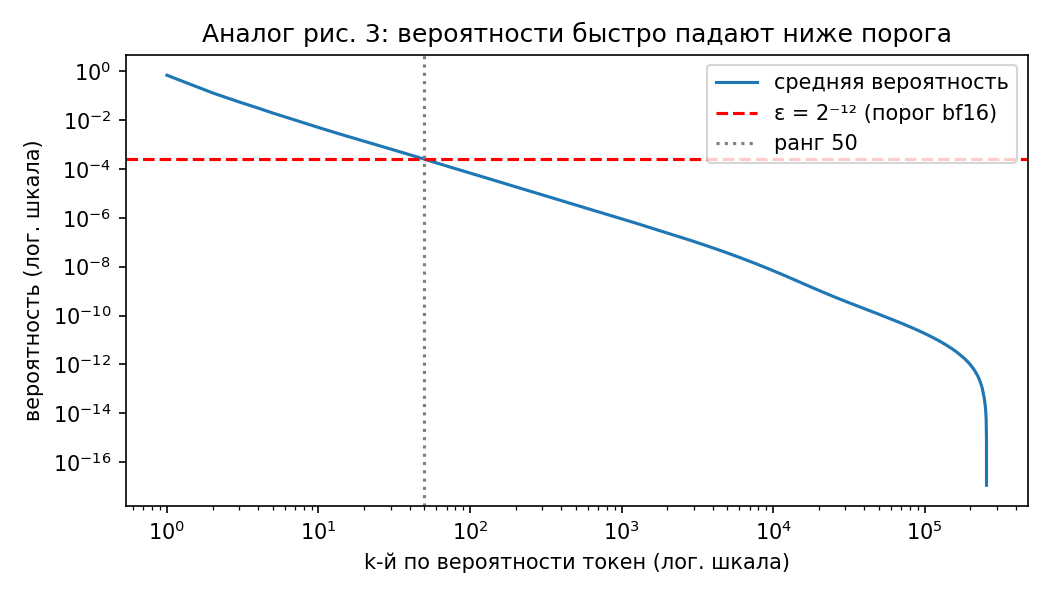

In [7]:
display(Image(filename=str(RES / "sparsity_prob_by_rank.png"), width=700))

- Выше порога лишь 0,014% элементов (в статье < 0,02%); средняя вероятность падает ниже порога ровно на 50-м токене, как в статье. Это объясняет, почему фильтрация почти не влияет на градиент.
- Сортировка словаря по среднему логиту сокращает число непустых блоков с 32% до 18% — почти вдвое меньше блоков, для которых нужен backward. Это наш дополнительный замер: отдельно в статье он не приводится.

## 4. LoRA fine-tuning: стандартный loss HF против CCE (аналог рис. 4 и рис. 1)

Оба прогона: один конфиг и сид, одинаковые батчи в одном порядке. Батч 4 × 2 (накопление) = 8 примеров, 300 шагов.
На 500 примерах это ≈ 5 эпох, поэтому модель запоминает данные и loss падает ниже, чем в статье (≈ 0,1 против ≈ 1,0).

Различия в конфигах: ['loss_impl', 'log_path']
|loss CCE − loss HF|: среднее 0.0069, максимум 0.0509


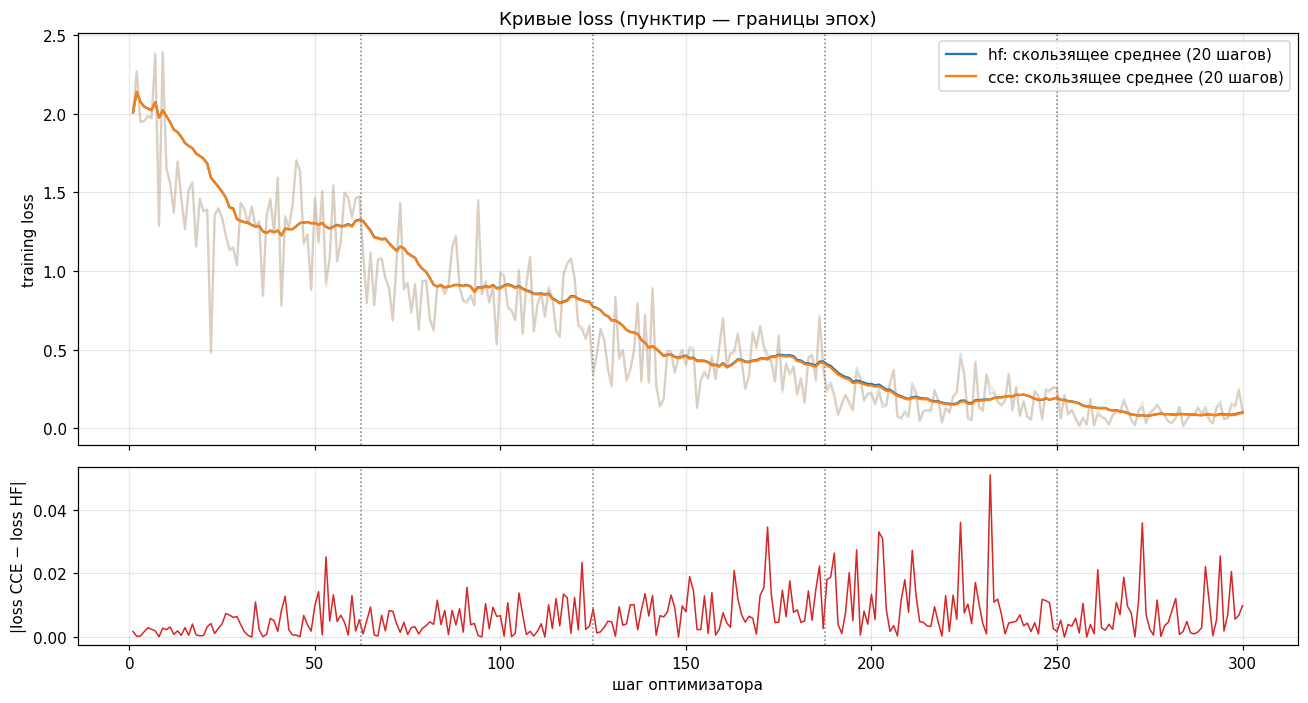

In [8]:
runs = {impl: pd.read_csv(RES / f"finetune_{impl}.csv") for impl in ("hf", "cce")}
cfg_hf = json.loads((RES / "finetune_hf.config.json").read_text())
cfg_cce = json.loads((RES / "finetune_cce.config.json").read_text())
diff_keys = [k for k in cfg_hf if cfg_hf[k] != cfg_cce[k]]
print("Различия в конфигах:", diff_keys)

N_EXAMPLES = 500
steps_per_epoch = N_EXAMPLES / (cfg_hf["batch_size"] * cfg_hf["grad_accum"])

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True, gridspec_kw={"height_ratios": [3, 1.3]})
for impl, color in (("hf", C_HF), ("cce", C_CCE)):
    df = runs[impl]
    axes[0].plot(df["step"], df["loss"], color=color, alpha=0.2)
    axes[0].plot(df["step"], df["loss"].rolling(20, min_periods=1).mean(), color=color,
                 label=f"{impl}: скользящее среднее (20 шагов)")
abs_diff = (runs["cce"]["loss"] - runs["hf"]["loss"]).abs()
axes[1].plot(runs["hf"]["step"], abs_diff, color="tab:red", lw=1)
for k in np.arange(steps_per_epoch, cfg_hf["num_steps"], steps_per_epoch):
    for ax in axes:
        ax.axvline(k, color="gray", ls=":", lw=1)
axes[0].set_ylabel("training loss")
axes[0].legend()
axes[0].set_title("Кривые loss (пунктир — границы эпох)")
axes[1].set_ylabel("|loss CCE − loss HF|")
axes[1].set_xlabel("шаг оптимизатора")
fig.tight_layout()
print(f"|loss CCE − loss HF|: среднее {abs_diff.mean():.4f}, максимум {abs_diff.max():.4f}")

In [9]:
def rjson(name):
    return json.loads((RES / name).read_text())

summary = pd.DataFrame({
    impl: {
        "loss до обучения": rjson(f"finetune_{impl}_init_loss.json")["init_loss"],
        "loss, последние 50 шагов": df["loss"].tail(50).mean(),
        "пиковая память за шаг, медиана, МБ": df["peak_mem_mb"].median(),
        "пиковая память за шаг, максимум, МБ": df["peak_mem_mb"].max(),
        "токенов/с, медиана": df["tokens_per_s"].iloc[5:].median(),
        "макс. батч при длине 512": rjson(f"finetune_{impl}_max_batch.json")["max_batch"],
    }
    for impl, df in runs.items()
})
summary["CCE / HF"] = summary["cce"] / summary["hf"]


def fmt_value(x: float) -> str:
    # Большие числа — целыми с разделителем тысяч, loss — с 4 знаками.
    return f"{x:,.0f}" if abs(x) >= 100 else (f"{x:.0f}" if float(x).is_integer() else f"{x:.4f}")


summary.style.format({"hf": fmt_value, "cce": fmt_value, "CCE / HF": "×{:.2f}"})

,hf,cce,CCE / HF
loss до обучения,1.8616,1.8606,×1.00
"loss, последние 50 шагов",0.0923,0.0906,×0.98
"пиковая память за шаг, медиана, МБ","12,222","9,507",×0.78
"пиковая память за шаг, максимум, МБ","21,975","15,665",×0.71
"токенов/с, медиана","1,515","1,640",×1.08
макс. батч при длине 512,6,10,×1.67


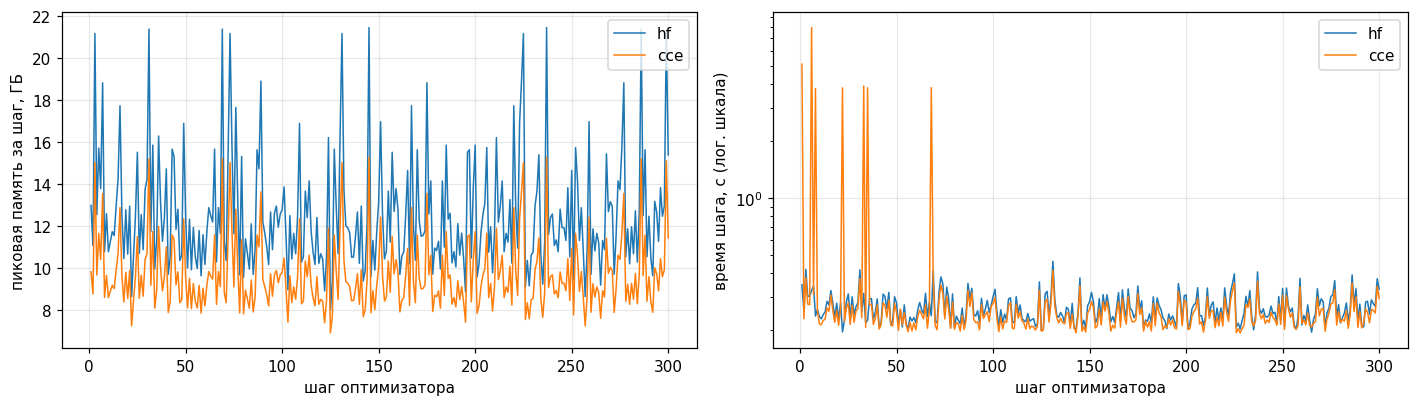

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for impl, color in (("hf", C_HF), ("cce", C_CCE)):
    df = runs[impl]
    axes[0].plot(df["step"], df["peak_mem_mb"] / 1024, color=color, lw=1, label=impl)
    axes[1].plot(df["step"], df["step_time_s"], color=color, lw=1, label=impl)
axes[0].set_ylabel("пиковая память за шаг, ГБ")
axes[1].set_ylabel("время шага, с (лог. шкала)")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("шаг оптимизатора")
    ax.legend()
fig.tight_layout()

- **Loss до обучения** совпадает (1,8616 против 1,8606): патч CCE считает тот же loss, что HF.
- **Кривые совпадают**: средняя разница по шагам 0,007, за последние 50 шагов 0,092 против 0,091. Фильтрация градиента обучению не мешает.
- **Память**: пик за шаг меньше на 22–29%, максимальный батч при длине 512 — 10 против 6 (×1,7). Это скромнее ×9,5 на рис. 1: там 16 GPU с FSDP и чекпоинтингом активаций, где логиты — основная часть памяти. У нас без чекпоинтинга большую часть занимают активации 26 слоёв.
- **Скорость** шага у CCE на 8% выше по медиане. Редкие выбросы до 4–8 с — автотюнинг ядер Triton: число токенов с loss в каждом батче своё, и под новый размер ядро настраивается заново.
- Ступеньки на кривой loss на границах эпох — следствие запоминания 500 примеров.

## Выводы

| Утверждение статьи | Результат |
|---|---|
| Фильтрация не искажает градиент | ✅ ошибка ∇E на уровне шума bf16 (≈ 2%), как у `torch.compile` |
| Память CCE ≈ размер градиентов | ✅ 1163 МБ при нижней границе 1161; ×24 меньше Baseline — как в статье |
| Без потери скорости | ❌ на H100 MIG CCE на 7% медленнее Baseline и в 2,2 раза медленнее `torch.compile` |
| Фильтрация ускоряет backward | ✅ ×2,3 (в статье ×2,5) |
| Softmax разрежен | ✅ 0,014% элементов выше порога, порог на 50-м токене |
| Обучение с CCE не отличается | ✅ кривые совпадают, loss до обучения совпадает |
| Больший батч | ✅ ×1,7 при LoRA без чекпоинтинга (в статье ×9,5 в другой конфигурации) |

Главный результат статьи — память последнего слоя на уровне самих градиентов — воспроизводится точно.
Выигрыш по времени зависит от железа и версии PyTorch: на H100 и PyTorch 2.7 `torch.compile` быстрее CCE, хотя расходует в 4,4 раза больше памяти.

**Ограничения:** один MIG-слайс вместо целой GPU, один сид в обучении, 500 примеров (≈ 5 эпох), LoRA вместо полного fine-tuning; Liger, Torch Tune и CCE без сортировки словаря не измерялись.